In [1]:
%reload_ext autoreload
%autoreload 2


In [2]:

import os
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.98"

import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")


Duplicate key in file '/weka/macke/mgloeckler90/dmri/dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')
Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [ ]:
from dmri.train.utils import load_cfg, load_checkpoint

#checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/new_multishell_ball3stick_simformer6_v_pred")
checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/msb3s_2_4_6_128_noscore")
graphdef, params,  state = nnx.split(model, nnx.Param,  ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, state)
model.eval()

In [89]:
sim_type = model.tokenizer.simulator

In [90]:
out = jax.vmap(simulator[0])(jax.random.split(jax.random.PRNGKey(1), num=200))

In [91]:
acq = out["acq"]
p_mask = out["mask_prior"]
masks = out["model_mask"]
theta = out["theta"]
x_os = out["x"]
#score = out["target_score"]

[ True  True  True  True  True]
[ 7.1167884  8.310825   9.710385   9.759955  10.943964  11.43213
 11.50792   12.394543  12.478694  12.54411   13.325412  13.843321
 13.983688  14.661508  15.601845  16.232363  16.907457  17.805496
 17.981127  18.886324  19.068316  19.158934  19.837772  19.993172
 20.22856   20.663818  21.650246  21.960768  23.21142   23.534945
 23.821339  23.912521  23.971228  24.034006  24.413502  24.87476
 24.995003  26.714746  27.061205  27.359415  27.986183  28.018393
 28.088621  28.40397   28.73971   28.886036  29.720623  29.776934
 29.88568   30.170439  30.79526   31.228233  31.543419  32.820206
 33.02145   33.173676  33.95636   33.96371   34.249863  34.820354
 35.298214  35.482063  35.928207  36.758568  36.976845  37.02677
 37.279438  37.997936  38.355362  38.656025  38.828056  39.094917
 39.62598   39.983334  40.206455  40.37034   40.529438  40.68284
 40.78209   40.797737  41.02101   41.581764  41.952915  42.027607
 42.11958   42.37146   42.60199   44.1049    44.

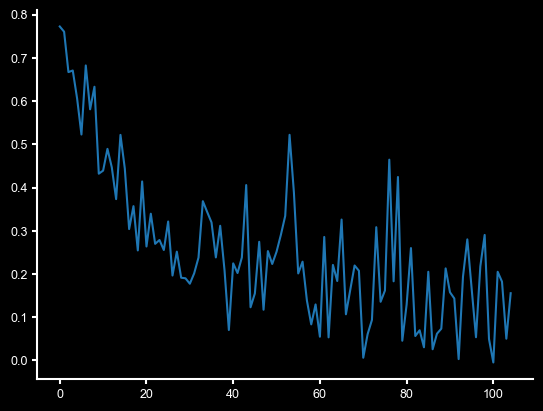

In [118]:
#idx = 37
#idx = 42
idx=41
print(masks[idx])
print(acq.qvals[idx])
plt.plot(x_os[idx])

In [119]:
from probjax.nn.nets.denoising_diffusion_model import VSolverConfig, EDMSolverConfig


In [120]:
model.inference_decoder.solver_cfg = VSolverConfig(model.inference_decoder.schedule)
#model.inference_decoder.solver_cfg = EDMSolverConfig(model.inference_decoder.schedule)
#model.inference_decoder.solver_cfg.ode_method = "exp_ab2_scalarL"

In [121]:
from functools import partial
sample_fn = jax.jit(jax.vmap(partial(model.sample_theta, t_min=0.,num_steps=256, model_mask=masks[idx]), in_axes=(0,None, None)))

In [122]:
thetas_post = sample_fn(jax.random.split(jax.random.key(0), 10_000), jax.tree_util.tree_map(lambda x: x[idx], acq), x_os[idx])

In [123]:
%%timeit
thetas_post = sample_fn(jax.random.split(jax.random.key(0), 10_000), jax.tree_util.tree_map(lambda x: x[idx], acq), x_os[idx])
thetas_post.block_until_ready()

1.84 s ± 177 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [124]:
theta_mask = sim_type.theta_mask(masks[idx])

In [125]:
params1 = sim_type.from_theta(theta[0], model_mask=masks[idx]).params
params2 = sim_type.from_theta(theta[0]*(sim_type.theta_mask(masks[idx])), model_mask=masks[idx]).params

In [126]:
params1["model_fractions"] - params2["model_fractions"]

Array([0., 0., 0., 0.], dtype=float32)

In [127]:
for i in range(len(sim_type.model_types)):
    if masks[idx][i]:
        model1 = params1["model_compartments"][i]
        model2 = params2["model_compartments"][i]
        print(jax.tree_util.tree_map(lambda x,y: x - y, model1.params, model2.params))

{}
{'mu': Array([0., 0.], dtype=float32)}
{'mu': Array([0., 0.], dtype=float32)}
{'mu': Array([0., 0.], dtype=float32)}


In [128]:
model1

In [129]:
sim_type.theta_mask(masks[idx])[9:]

Array([ True,  True,  True], dtype=bool)

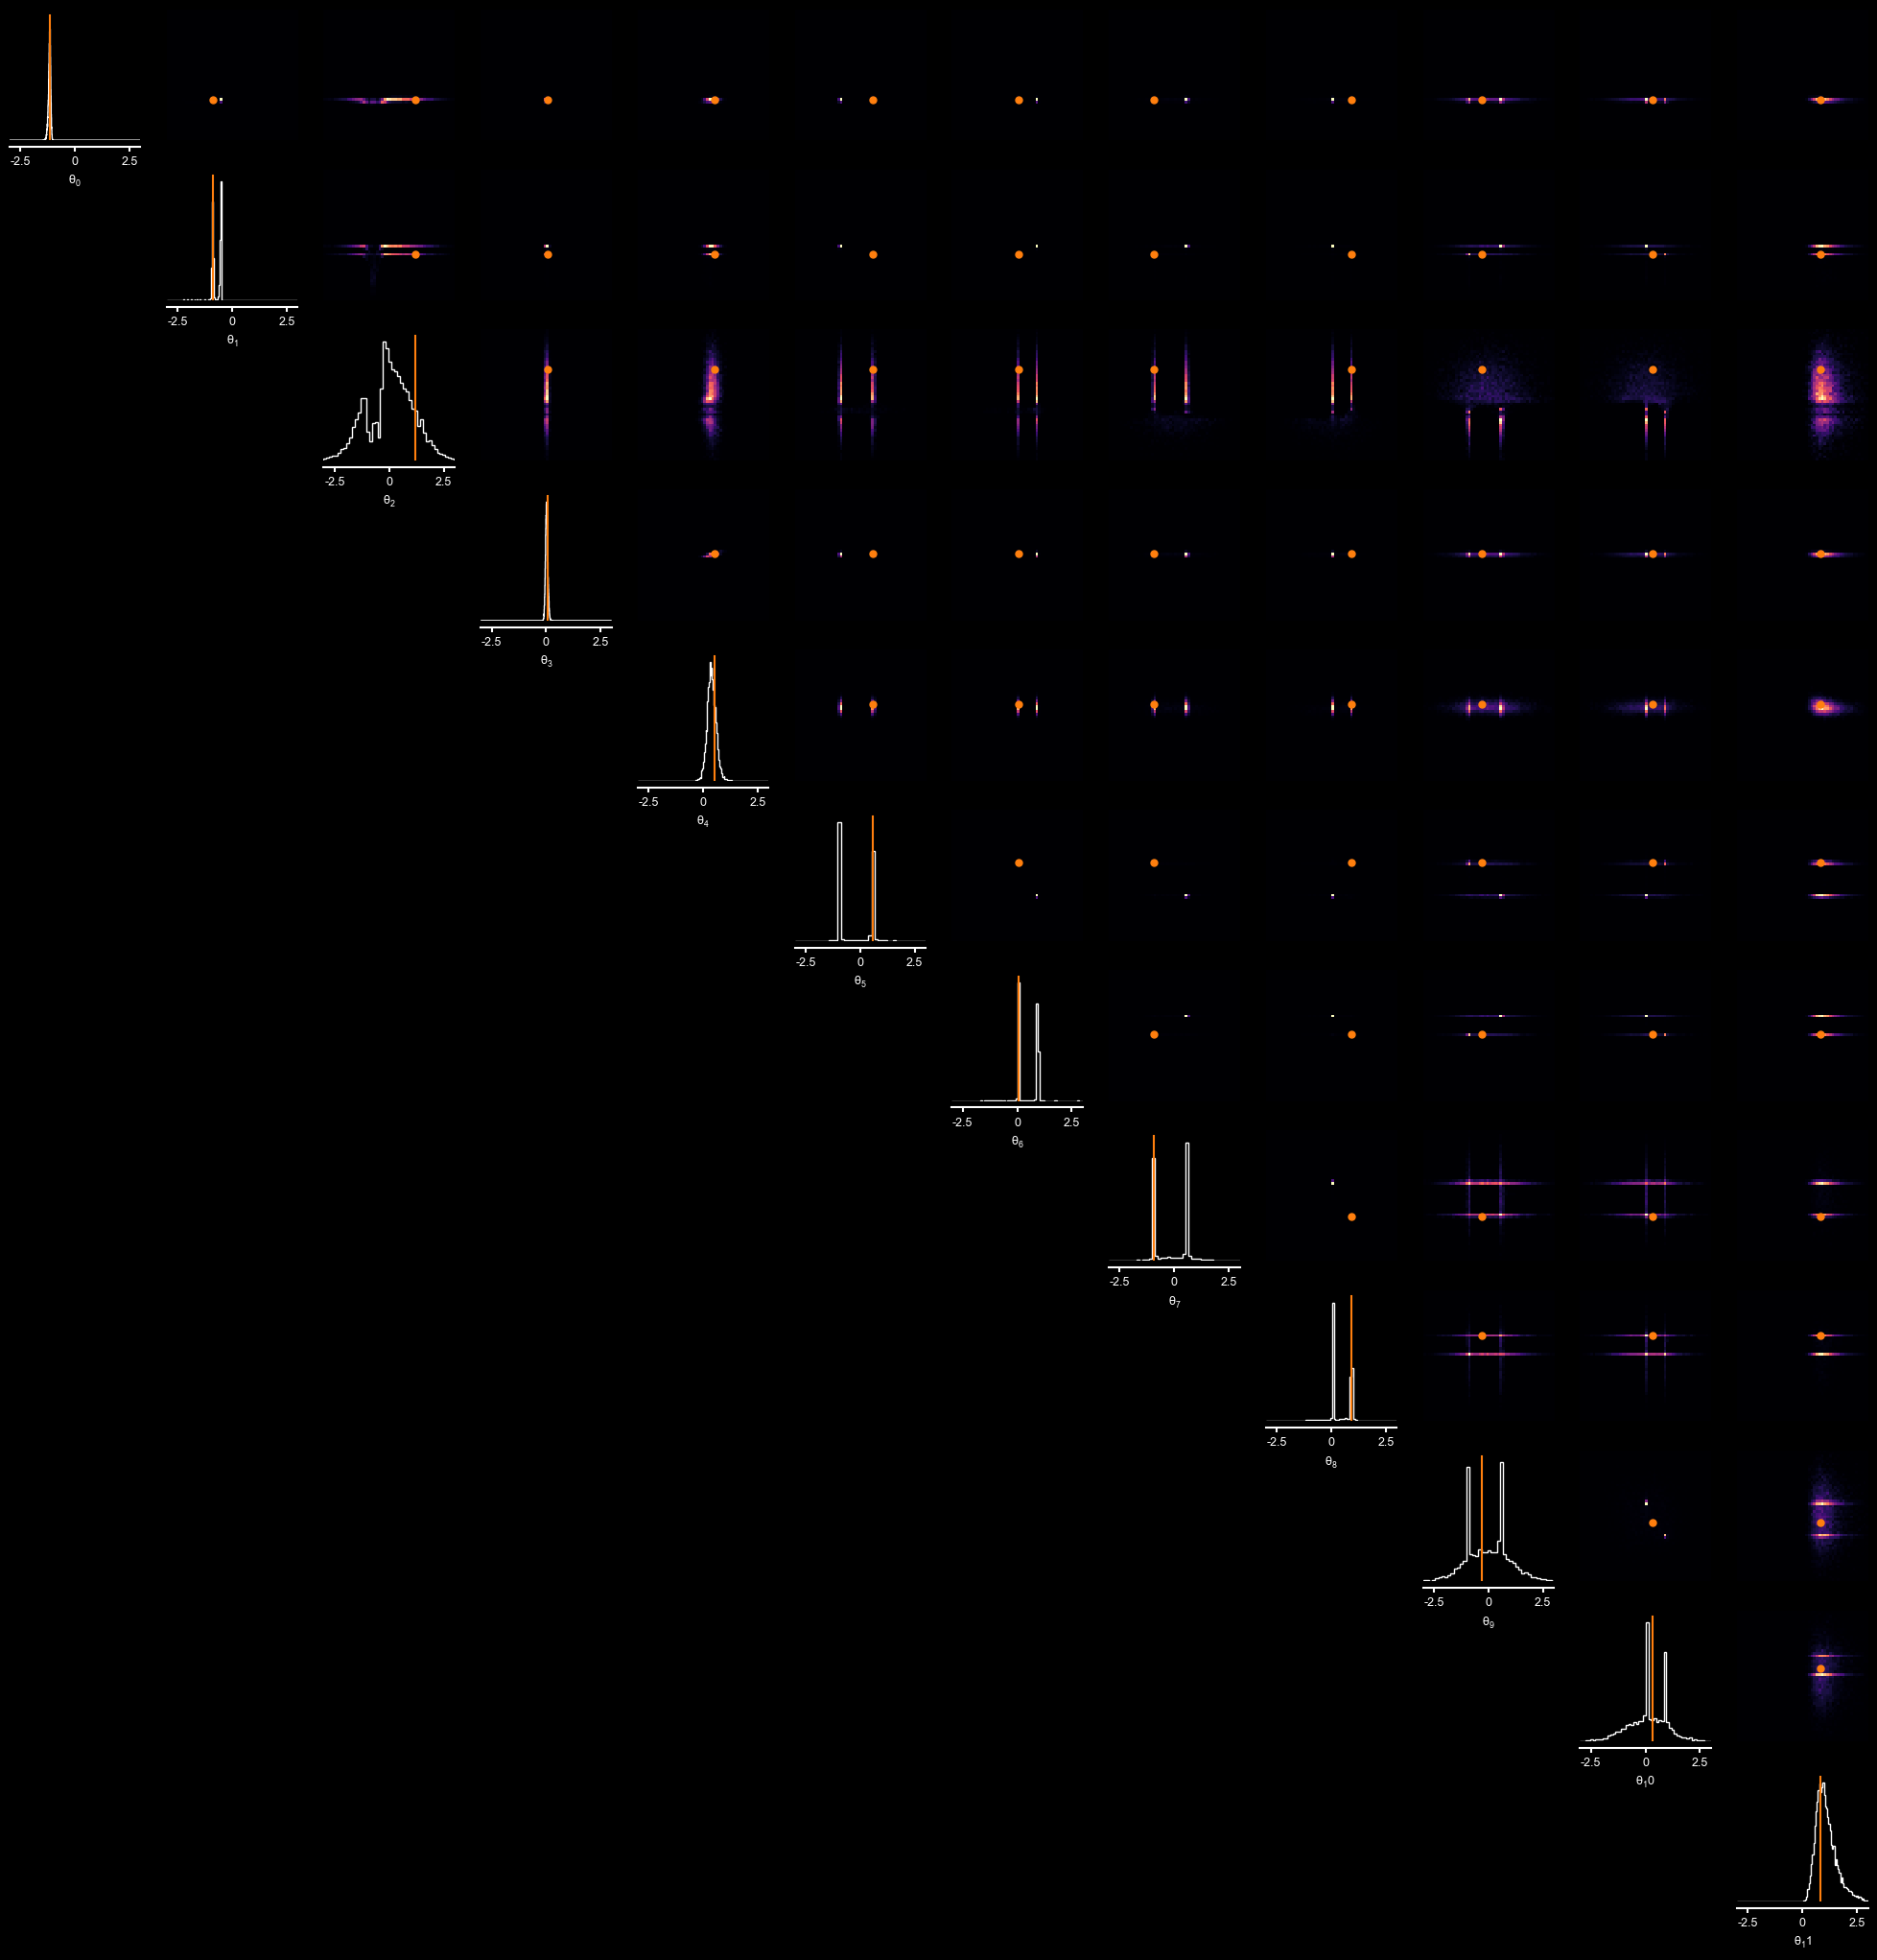

In [130]:
#import sbi
from sbi.analysis.plot import pairplot

_ = pairplot([thetas_post[:,theta_mask]], points=[theta[idx,theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[f'$\\theta_{i}$' for i in range(int(sum(theta_mask)))], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

In [131]:
from blackjax import hmc, tempered_smc,mala
from blackjax.smc.resampling import systematic


In [132]:
acq_single = jax.tree_util.tree_map(lambda x: x[idx], acq)

def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acq_single, rng=rng)

def log_likelihood_fn(theta):
    theta_mask = sim_type.theta_mask(masks[idx])
    theta = theta * theta_mask
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acq_single, x_os[idx])
    return ll

def log_prior_fn(theta):
    logpdf = jax.scipy.stats.norm.logpdf(theta, 0, 1)
    #theta_mask = sim_type.theta_mask(masks[idx])
    #logpdf = jnp.where(theta_mask, logpdf, 0.0)
    logpdf = jnp.sum(logpdf)
    return logpdf


In [133]:
jax.jit(sim_type.theta_mask)(masks[0]).shape

(12,)

In [134]:
log_likelihood_fn(thetas_post[0])

Array(262.82288, dtype=float32)

In [135]:
from blackjax import mala
@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.002, num_integration_steps=20, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    start_lam = 0.99
    state =state._replace(lmbda=start_lam)

    def step(state, rng):
        state, i = state
        new_state, info = smc.step(rng, state, 1.0)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        new_state = new_state._replace(lmbda=start_lam)
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [136]:
particles =smc(thetas_post)

ESS: 9961.3759765625, acc_rate: 0.9882993102073669
ESS: 9973.712890625, acc_rate: 0.9822515249252319
ESS: 9979.5634765625, acc_rate: 0.9808903336524963
ESS: 9982.8134765625, acc_rate: 0.980938732624054
ESS: 9984.87890625, acc_rate: 0.9802920818328857


In [137]:
particles.shape

(10000, 12)

In [138]:
def sliced_wasserstein_distance(X, Y, num_projections=5000, seed=0):
    # Get shapes and dimensions
    n_X, d_X = X.shape
    n_Y, d_Y = Y.shape

    # Generate random projections
    key = jax.random.key(seed)
    projections = jax.random.normal(key, (num_projections, d_X))
    projections = projections / jnp.linalg.norm(projections, axis=1, keepdims=True)

    # Project the data
    X_proj = jnp.dot(X, projections.T)
    Y_proj = jnp.dot(Y, projections.T)

    # Sort projections
    X_proj = jnp.sort(X_proj, axis=0)
    Y_proj = jnp.sort(Y_proj, axis=0)

    # Calculate distances
    distances = jnp.mean((X_proj - Y_proj) ** 2, axis=0)
    swd = jnp.sqrt(jnp.mean(distances))

    return swd

# Calculate SWD between particles and prior samples
swd = sliced_wasserstein_distance(particles[:, theta_mask], thetas_post[:, theta_mask])
print(f"Sliced Wasserstein Distance: {swd}")


Sliced Wasserstein Distance: 0.02289954386651516


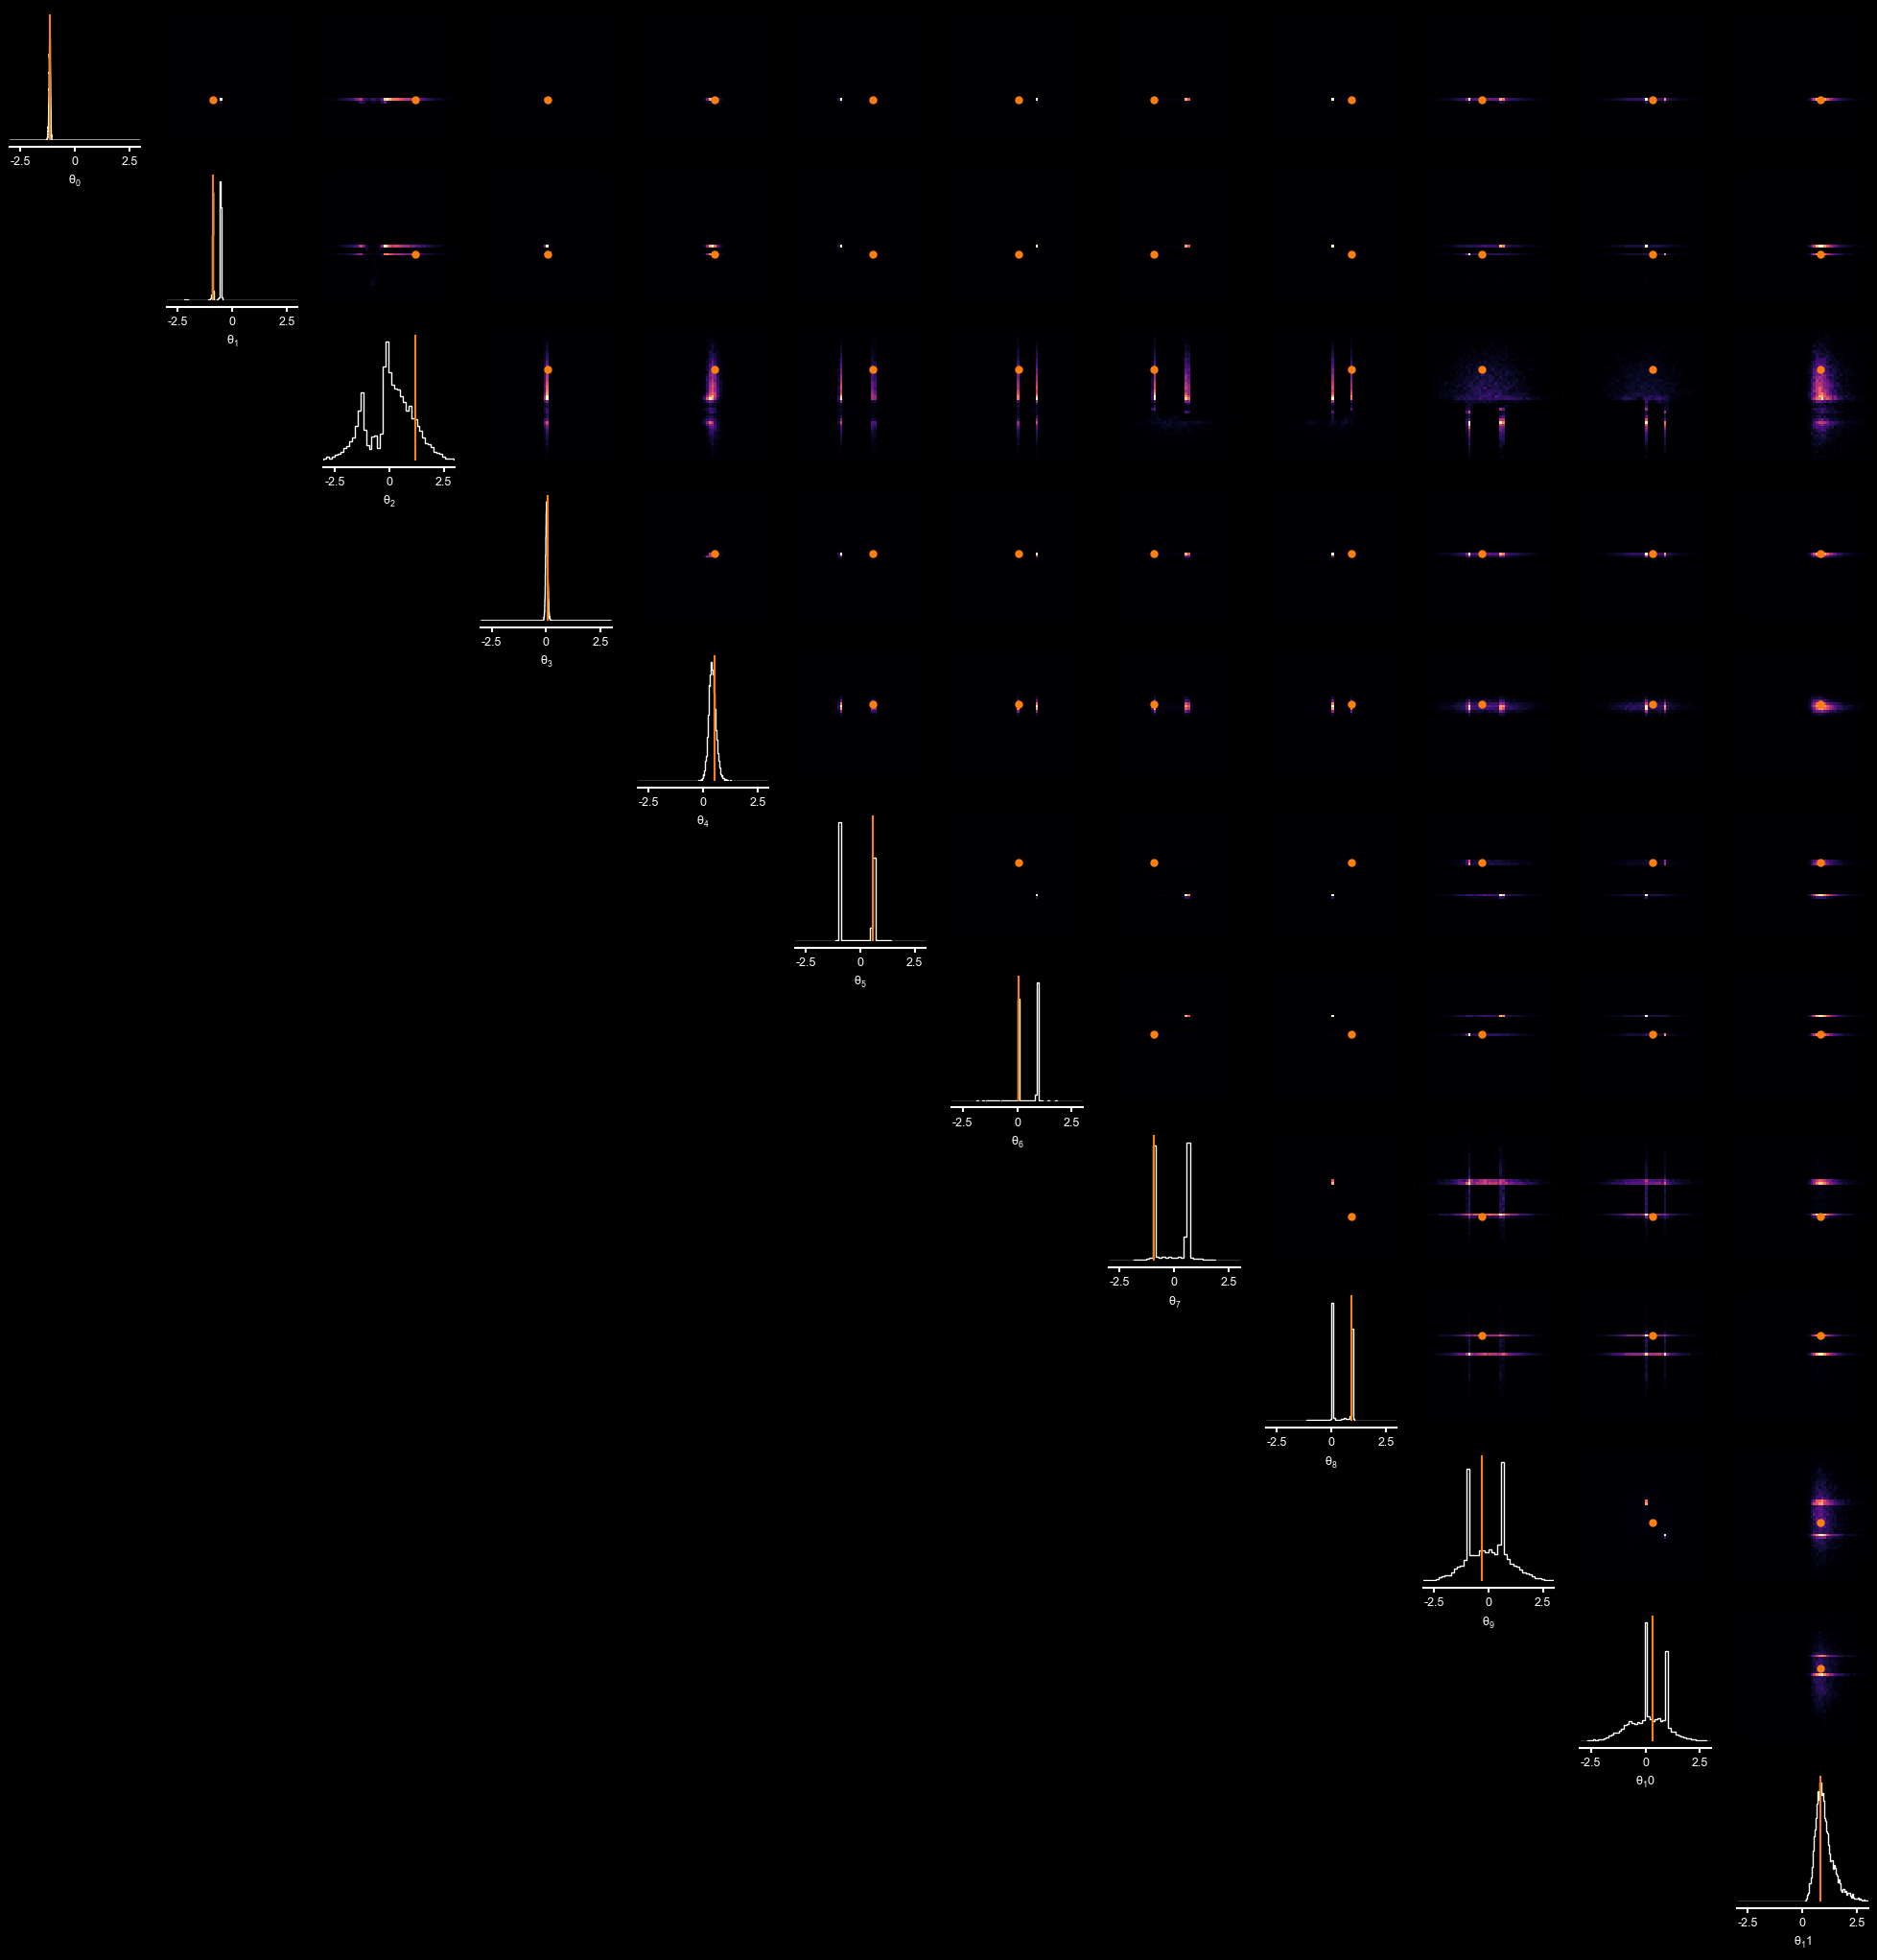

In [139]:
_ = pairplot([particles[:, theta_mask]], points=[theta[idx, theta_mask]], limits=[[-3,3]]*int(sum(theta_mask)), labels=[f'$\\theta_{i}$' for i in range(int(sum(theta_mask)))], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

Text(0, 0.5, 'MRI Signal')

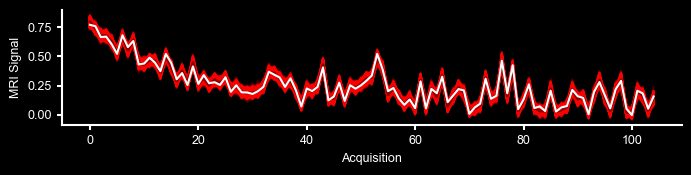

In [142]:

posterior_preds = jax.vmap(posterior_pred)(thetas_post, jax.random.split(jax.random.key(0), 10_000))
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds_sorted[::].T, label="posterior pred", color="red", alpha=0.2)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [144]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.simulator.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq=acq, x=x, num_steps=128, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


In [65]:
logp = jax.vmap(log_posterior,in_axes=(0, None,None,None))(thetas_post, masks[idx], acq_single, x_os[idx])

In [66]:
logq = jax.vmap(log_q,in_axes=(0, None,None,None))(thetas_post, masks[idx], acq_single, x_os[idx])

In [67]:
print(logq.shape)

(10000,)


In [68]:
logweights = logp[:1000] - logq[:1000]
weights = jax.nn.softmax(logweights - jax.scipy.special.logsumexp(logweights))
ess = 1/jnp.sum(weights**2)
print(f"ESS: {ess} / {logweights.shape[0]}")

ESS: 2.157184600830078 / 1000


(-500.0, 139.00158004760743)

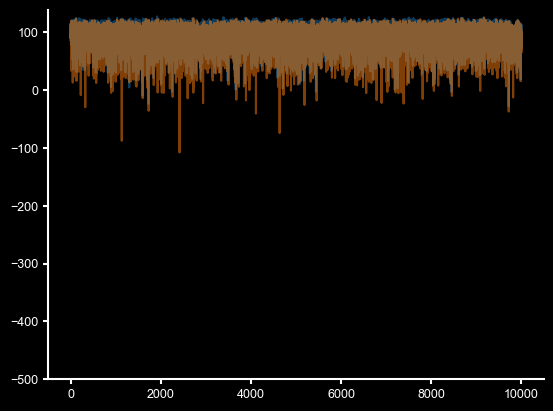

: 

In [ ]:
plt.plot(jax.vmap(log_posterior, in_axes=(0,None,None,None))(particles, masks[idx], acq_single, x_os[idx]), alpha=0.5)
plt.plot(jax.vmap(log_posterior, in_axes=(0,None,None,None))(thetas_post, masks[idx], acq_single, x_os[idx]), alpha=0.5)

plt.ylim(-500, None)

In [22]:
def to_fod(theta, model_mask, rng):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    return simulator.to_fod(no_isotropic=True).sample(rng, (200,)), simulator.model_fractions[1:].sum()

samples, weights = jax.vmap(to_fod, in_axes=(0,None,0))(particles, masks[idx], jax.random.split(jax.random.key(0), 10_000))

In [23]:
from dmri.utils.dmriutils import unitsphere_to_cartesian
def to_fractions_dirs(theta, model_mask):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    stick_mu = [m.mu for m in simulator.model_compartments if hasattr(m, 'mu')]
    return simulator.model_fractions[1:], jnp.stack(stick_mu)

def reorder_by_fraction(fractions, dirs):
    idx = jnp.argsort(-fractions)
    dirs = jax.vmap(unitsphere_to_cartesian)(dirs)
    return fractions[idx], dirs[idx]

fractions, dirs = jax.vmap(to_fractions_dirs, in_axes=(0,None))(particles, masks[idx])

In [24]:
fractions, dirs = jax.vmap(reorder_by_fraction, in_axes=(0,0))(fractions, dirs)

In [25]:
from dmri.utils.viz import plot_glyph_from_sticks

In [26]:
from dmri.utils.viz import plot_stereographic_scatter

In [27]:
samples_mixed = jax.random.choice(jax.random.key(0), samples.reshape(-1,3), shape=(50_000,), replace=False, p=jax.nn.softmax(jnp.repeat(weights, repeats=200)))

In [28]:
def make_dyads(v):
    dyadic_tensor = jnp.matmul(v, v.T) / v.shape[0]
    L, E = jnp.linalg.eigh(dyadic_tensor)

    ind = jnp.argsort(-L)
    v1 = E[:, ind[0]]
    disp = 1 - jnp.max(jnp.abs(L))
    # Calculate angular deviations from the principal eigenvector
    dot_prod = jnp.matmul(v.T, v1)
    angles = jnp.arccos(jnp.clip(dot_prod, -1, 1)) * (
        180 / jnp.pi
    )  # Convert to degrees
    angles = jnp.where(angles > 90, 180 - angles, angles)
    # Determine the cone angle at the specified percentile
    disp = jnp.percentile(angles, 0.9)

    return v1, disp
dyads1, disp1 = make_dyads(dirs[:,2].T)
dyads2, disp2 = make_dyads(dirs[:,1].T)
dyads3, disp3 = make_dyads(dirs[:,0].T)

In [29]:
from probjax.stats import watson, mixture, bingham

watson_dist1 = bingham(*bingham.fit(dirs[:,0]))
watson_dist2 = bingham(*bingham.fit(dirs[:,1]))
watson_dist3 = bingham(*bingham.fit(dirs[:,2]))


In [30]:
p_final = mixture.fit(samples_mixed[:], [watson_dist1, watson_dist2, watson_dist3], mixing_probs_init=fractions.mean(0), max_iter=100, tol=1e-9)
p_final = mixture(*p_final)


In [31]:
fractions.mean(0) / fractions.mean(0).sum()

Array([0.755, 0.238, 0.007], dtype=float32)

In [32]:
# Cluster assignment
pdfs = jnp.stack([comp.logpdf(samples_mixed) for comp in p_final.kwds["components"]], axis=1)
assignments = jnp.argmax(pdfs, axis=1)
weights = p_final.kwds["mixing_probs"]

In [33]:
weights

Array([0.743, 0.244, 0.013], dtype=float32)

In [34]:
p_final.kwds["components"][0].logpdf(samples_mixed).max()

Array(6.851, dtype=float32)

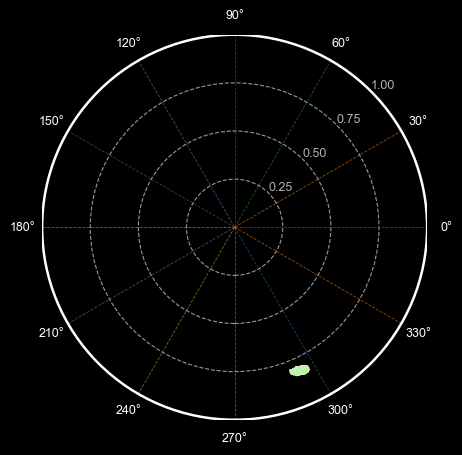

In [50]:
plot_stereographic_scatter(samples_mixed[assignments==0], axial=True, s=1, point_alpha=0.5)

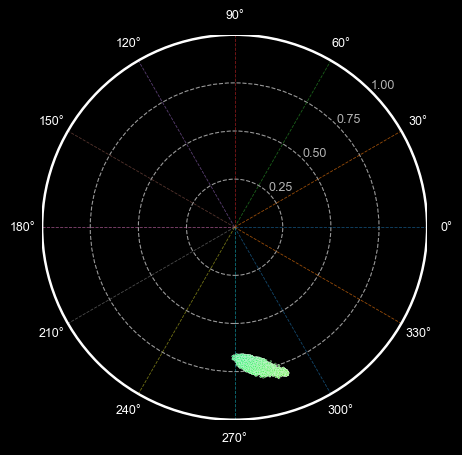

In [52]:
plot_stereographic_scatter(samples_mixed[assignments==1], axial=True, s=2, point_alpha=0.5)

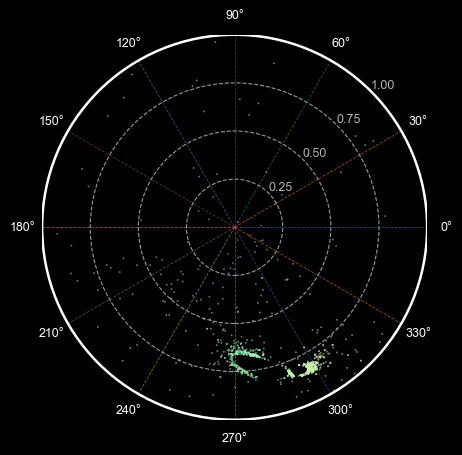

In [54]:
plot_stereographic_scatter(samples_mixed[assignments==2], axial=True, s=1, point_alpha=0.5)

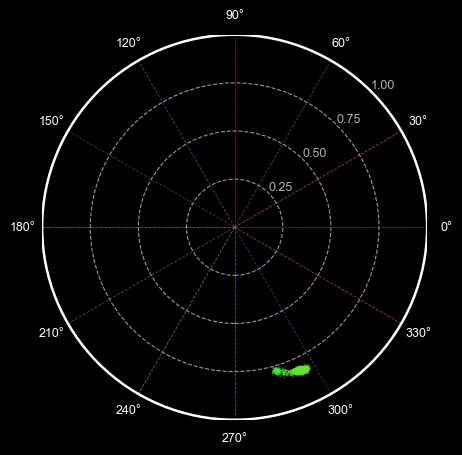

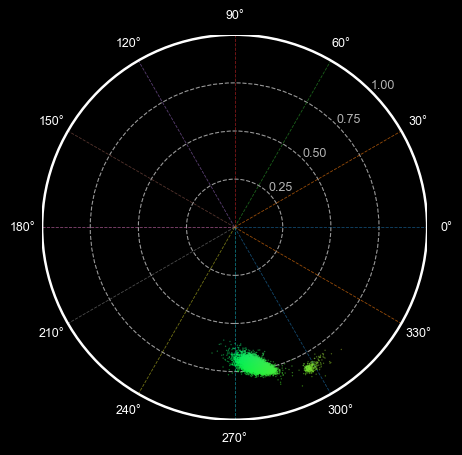

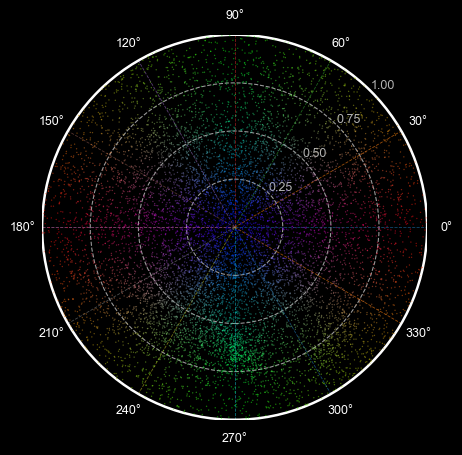

In [48]:
plot_stereographic_scatter(dirs[:, 0], axial=True, angle_step=30, ring_radii=(0.25, 0.5, 0.75, 1.0), s=1, point_alpha=0.5, point_color="orientation", edge=False)
plot_stereographic_scatter(dirs[:, 1], axial=True, angle_step=30, ring_radii=(0.25, 0.5, 0.75, 1.0), s=1, point_alpha=0.5, point_color="orientation", edge=False)
plot_stereographic_scatter(dirs[:, 2], axial=True, angle_step=30, ring_radii=(0.25, 0.5, 0.75, 1.0), s=1, point_alpha=0.5, point_color="orientation", edge=False)

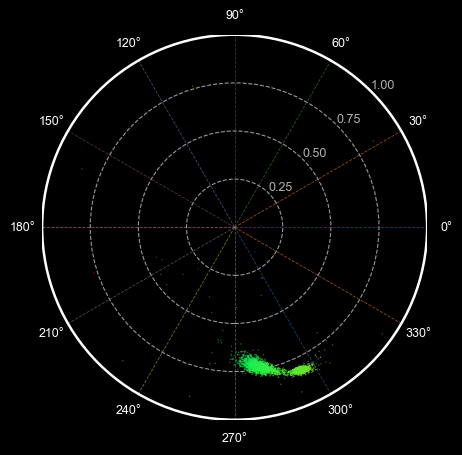

In [46]:
plot_stereographic_scatter(samples_mixed[:10_000], axial=True, angle_step=30, ring_radii=(0.25, 0.5, 0.75, 1.0), s=1, point_alpha=0.5, point_color="orientation", edge=False)

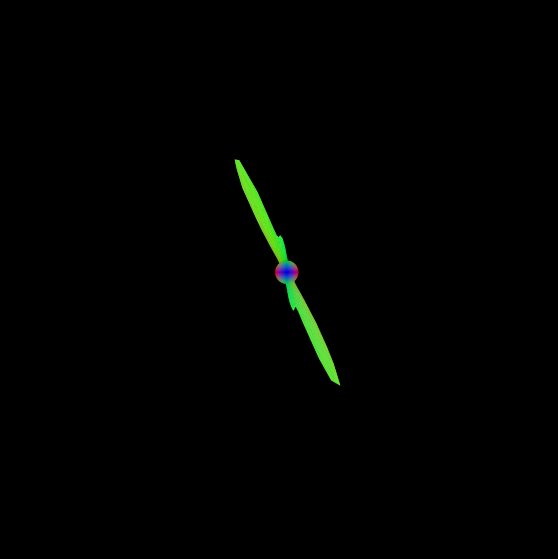

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
plot_glyph_from_sticks(samples_mixed, kappa=200.0, grid_points=8000, view='xy', show_peaks=False, r_scale=2.)

In [126]:
from dmri.utils.viz import plot_spherical_distribution_cartesian

In [127]:
plot_spherical_distribution_cartesian(fods[:,0], fods[:,1])

NameError: name 'fods' is not defined

In [1]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

folder_name = "data"
data, affine = load_nifti(f"../data/{folder_name}/data.nii.gz")
brain_mask, _ = load_nifti(f"../data/{folder_name}/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs(f"../data/{folder_name}/bvals", f"../data/{folder_name}/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, None)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

/tmp/ipykernel_1973506/1099530353.py:19: RuntimeWarning: divide by zero encountered in divide
  data_norm = data / S0[..., None]
/tmp/ipykernel_1973506/1099530353.py:19: RuntimeWarning: invalid value encountered in divide
  data_norm = data / S0[..., None]


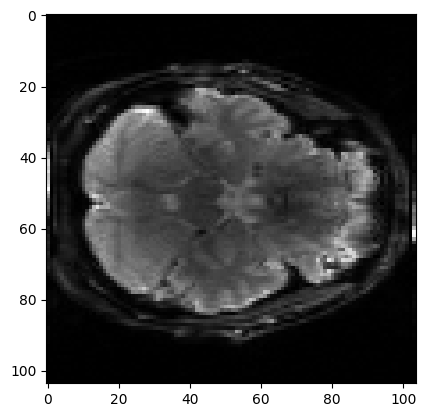

In [10]:
import matplotlib.pyplot as plt
plt.imshow(data[..., 20, 0], cmap="gray")

In [69]:
np.unique(bvals_rounded)

array([   0., 1000., 2000.])

In [70]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


In [71]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [72]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [73]:
exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = np.clip(full_data_flat_in_brain, 0, exclude_outliers)

In [74]:
acq = acquisition_scheme(np.array(bvals), np.array(bvecs))

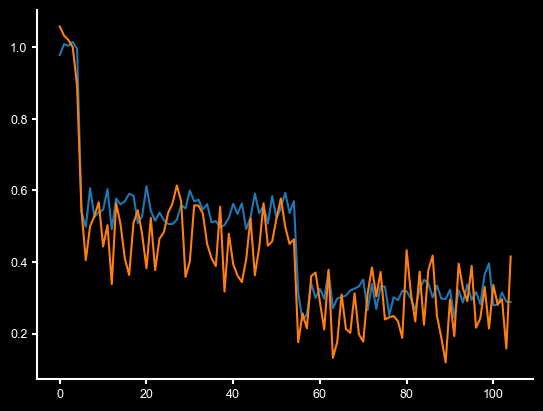

In [76]:
#plt.plot(full_data_flat_in_brain[21_800])
plt.plot(full_data_flat_in_brain[24_800])
#plt.plot(full_data_flat_in_brain[70_000])
# plt.plot(full_data_flat_in_brain[27_800])
# plt.plot(full_data_flat_in_brain[30_800])
# plt.plot(full_data_flat_in_brain[100_000])
# plt.plot(full_data_flat_in_brain[200_000])
plt.plot(full_data_flat_in_brain[100_200])


In [77]:
from functools import partial
#x_o = full_data_flat_in_brain[21_800]
x_o = full_data_flat_in_brain[24_800]
#x_o = full_data_flat_in_brain[70_000]
#x_o = full_data_flat_in_brain[27_800]
# x_o = full_data_flat_in_brain[30_800]
x_o = full_data_flat_in_brain[100_000]
x_o = full_data_flat_in_brain[200_000]
#x_o = full_data_flat_in_brain[100_200]
#model_mask = jnp.ones(5, dtype=jnp.bool)
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)


In [80]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=512, max_noise=80, model_mask=model_mask, sample_method="ode"), in_axes=(0,None, None))(jax.random.split(jax.random.key(0), 10_000), acq, x_o)

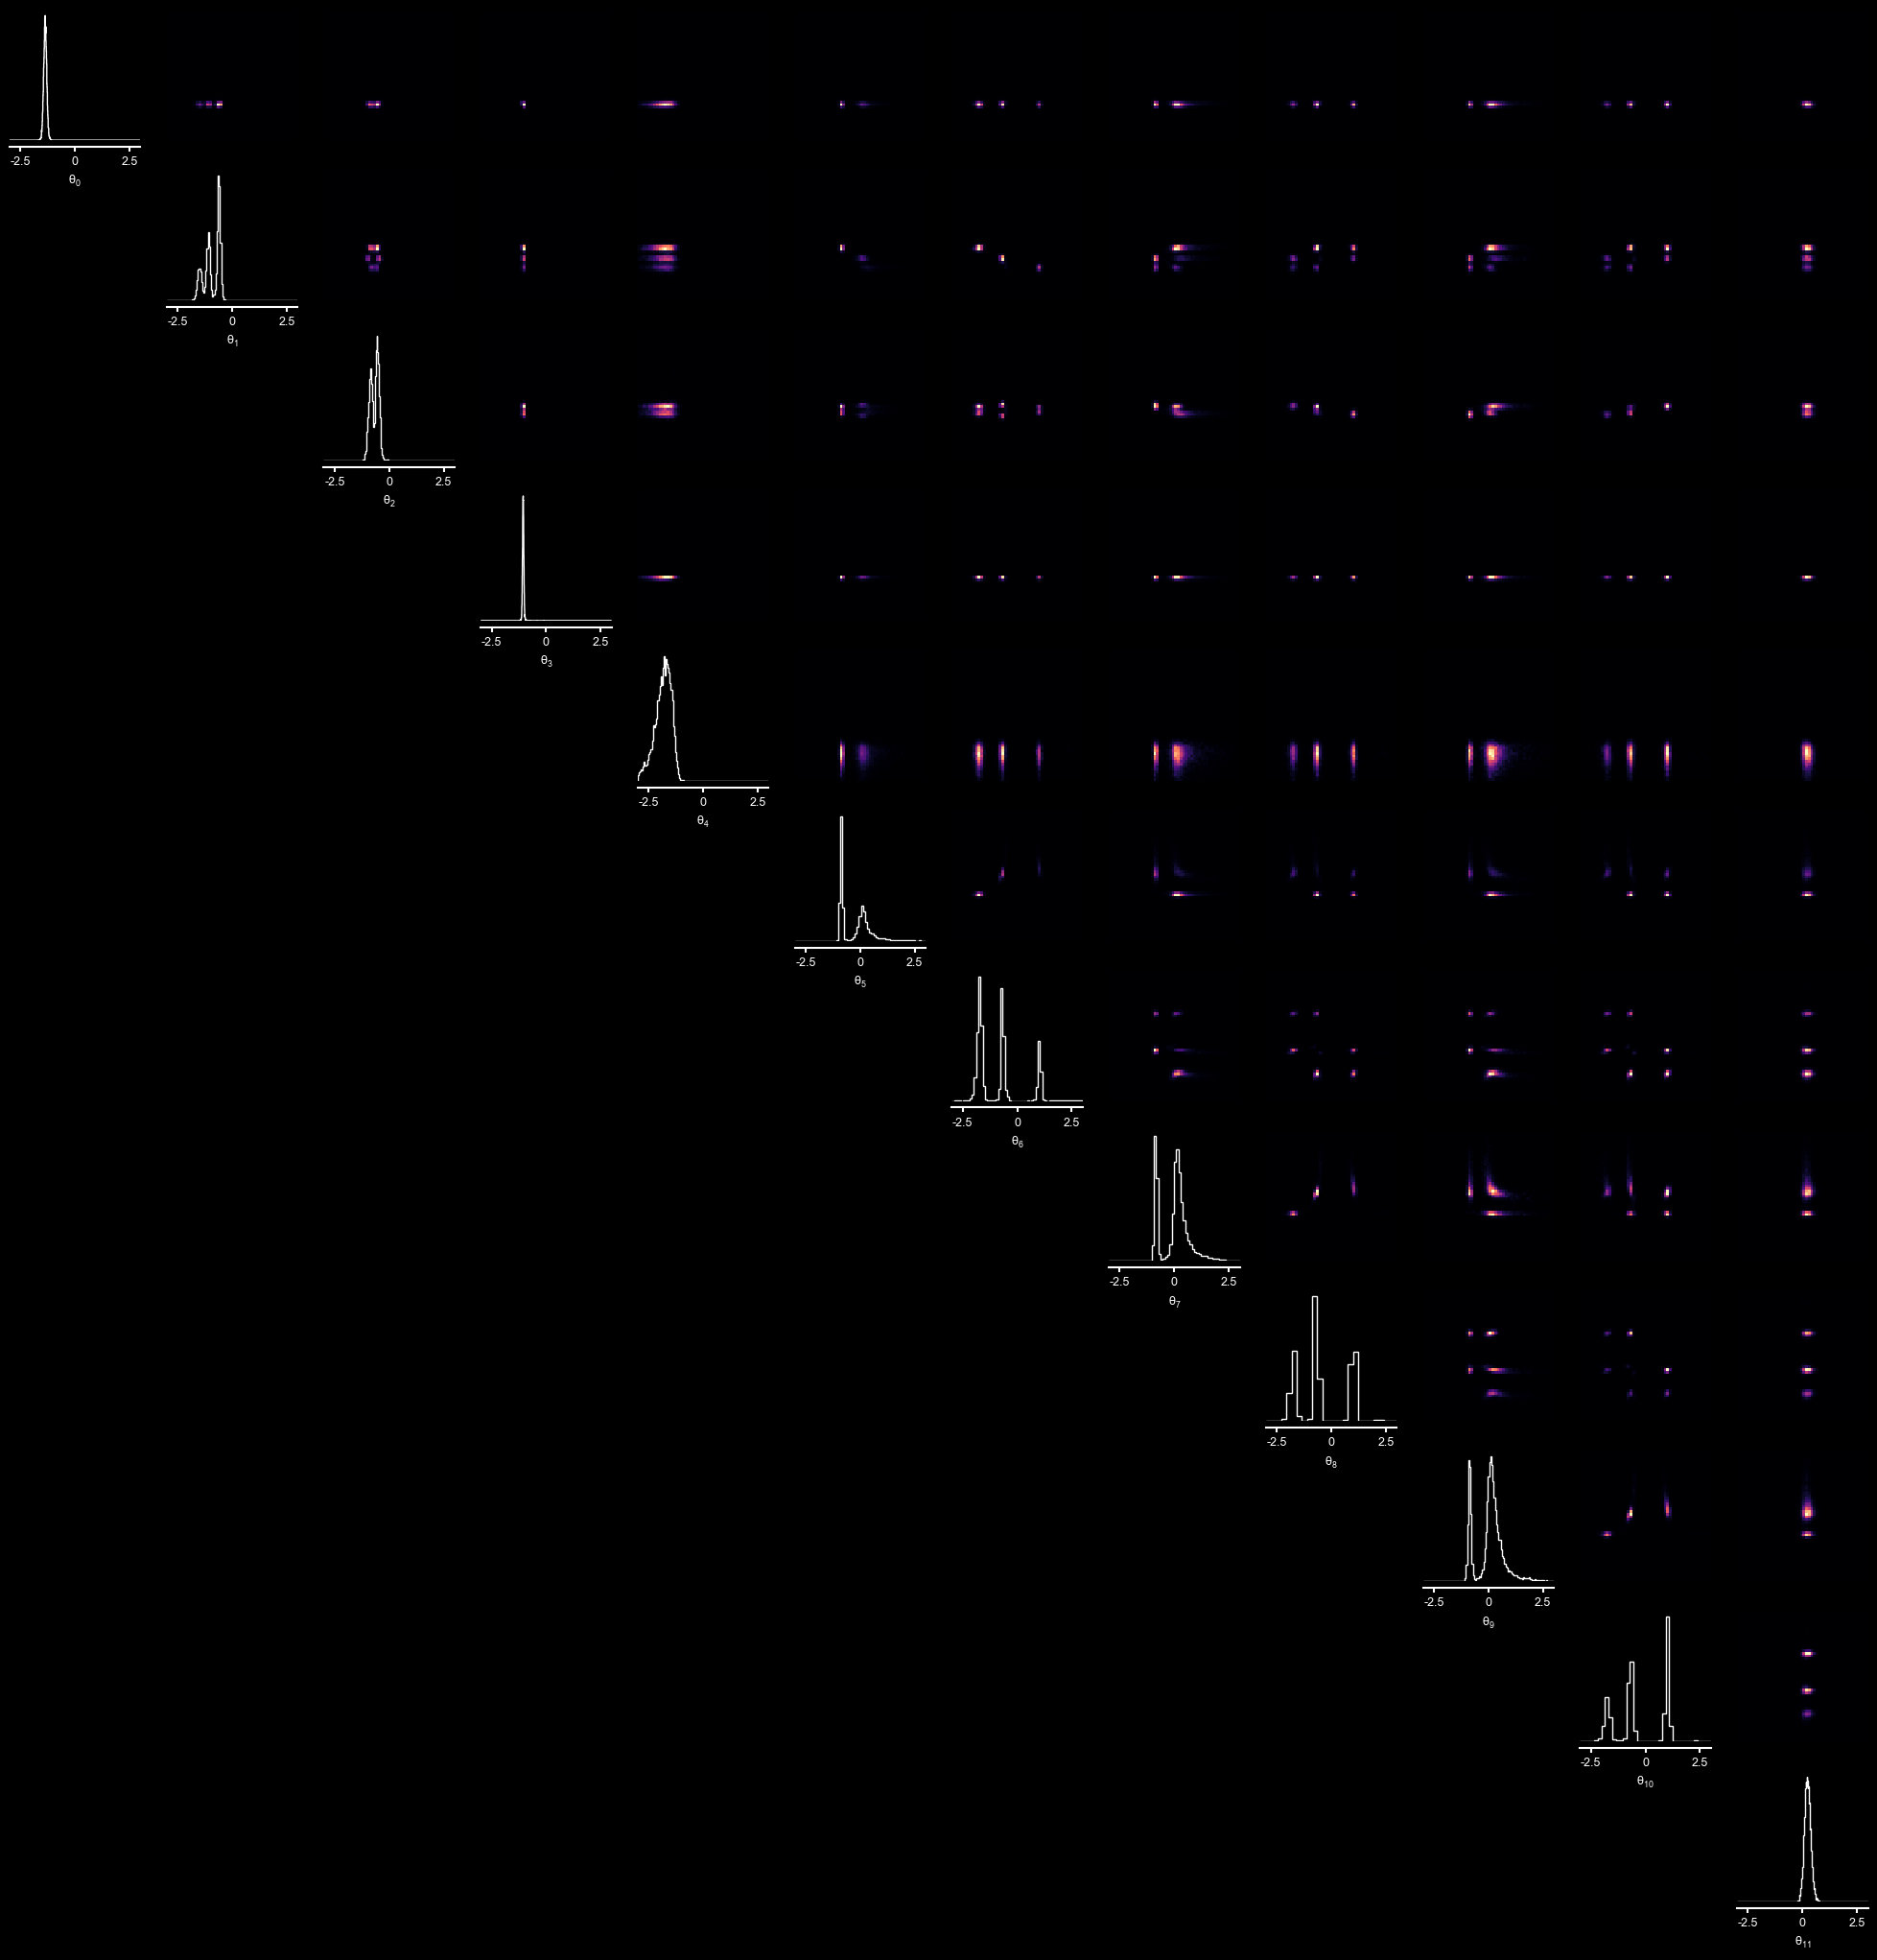

In [81]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot([thetas_post], limits=[[-3,3]]*12, labels=[f'$\\theta_{{{i}}}$' for i in range(12)], figsize=(25, 25), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])

In [82]:
from functools import partial
from blackjax import hmc, tempered_smc
from blackjax.smc.resampling import systematic

def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=model_mask)
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals, acq.bvecs), x_o)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)


@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.005, num_integration_steps=20, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        new_state, info = smc.step(rng, state, 1.)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        new_state = new_state._replace(lmbda=0.99)
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [83]:
particles =smc(thetas_post)

ESS: 9770.20703125, acc_rate: 0.9735937118530273
ESS: 9913.2451171875, acc_rate: 0.9636539816856384
ESS: 9950.4521484375, acc_rate: 0.9515936374664307
ESS: 9965.185546875, acc_rate: 0.9454988241195679
ESS: 9973.4609375, acc_rate: 0.9434554576873779


In [84]:
sliced_wasserstein_distance(particles, thetas_post)

Array(0.064, dtype=float32)

Text(0, 0.5, 'MRI Signal')

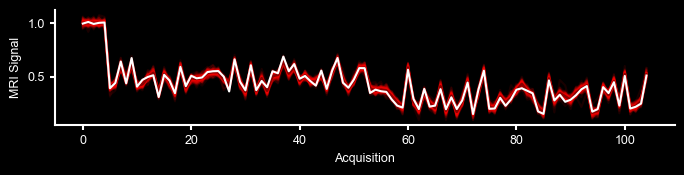

In [85]:
#idx=1000_22
posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 10_000))


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds[::100].T, label="posterior pred", color="red", alpha=0.1)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

#fig.savefig(f"figures_parameter_inference/posterior_pred_idx={idx}.png")

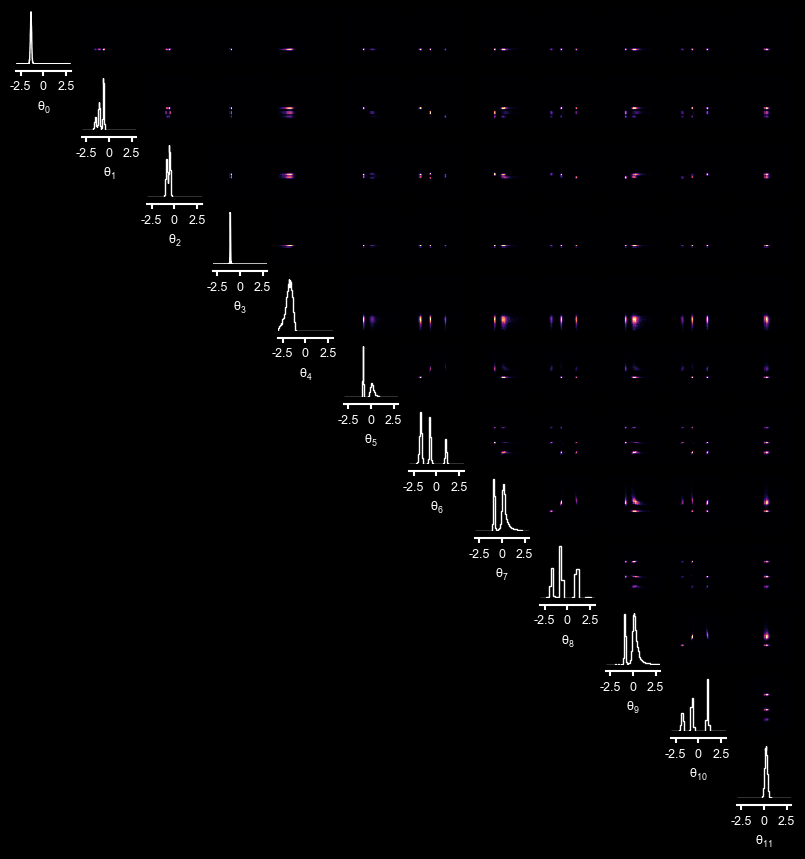

In [86]:
import sbi
from sbi.analysis.plot import pairplot

fig, axes = pairplot([thetas_post], limits=[[-3,3]]*12, labels=[f'$\\theta_{{{i}}}$' for i in range(12)], figsize=(10, 10), upper_kwargs=[dict(mpl_kwargs=dict(cmap="magma", origin="lower", aspect="auto"))], diag_kwargs=[dict(mpl_kwargs=dict(color="white"))])
#fig.savefig(f"figures_parameter_inference/posterior_particles_idx={idx}.png")

In [87]:

@jax.jit
def estimate_marginal_likelihood_naive(rng,model_mask, x_o):
    n_samples = 100_000_000
    n_batches = 20

    def scan_body(carry, rng):
        thetas = jax.random.normal(rng, (n_samples, 12))
        ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
        # Accumulate log sum exp in the loop
        new_carry = jax.scipy.special.logsumexp(jnp.array([carry, jax.scipy.special.logsumexp(ll)]))
        return new_carry, None

    initial_carry = -jnp.inf  # Initialize with -inf for log sum exp
    final_sum, _ = jax.lax.scan(scan_body, initial_carry, jax.random.split(rng, n_batches))

    N = n_samples * n_batches
    return final_sum - jnp.log(N)

@jax.jit
def estimate_marginal_likelihood(rng,model_mask, x_o):
    n_samples = 20_000
    thetas, log_probs = jax.vmap(partial(model.sample_and_log_prob_theta, num_steps=128, max_noise=80), in_axes=(0,None,None,None,None))(jax.random.split(rng, n_samples), acq.bvals, acq.bvecs, x_o, model_mask)
    prior_probs = jax.scipy.stats.norm.logpdf(thetas, 0, 1).sum(-1)
    logweights = prior_probs - log_probs
    true_ll = jax.vmap(partial(loglikelihood, mask=model_mask, acq=acq, x=x_o))(thetas)
    importance_weighted_ll = logweights + true_ll
    return jax.scipy.special.logsumexp(importance_weighted_ll) - jnp.log(n_samples)


def prior_log_prob(model_mask, p):
    N = model_mask.shape[0]
    log_probs = []

    for i in range(N-1):
        if model_mask[i] != 1:
            # If the forced index isn't 1, this component gives zero prob.
            log_probs.append(-jnp.inf)
        else:
            mask_except_i = jnp.concatenate([model_mask[:i], model_mask[i+1:]])
            logpmf_except_i = jax.scipy.stats.bernoulli.logpmf(mask_except_i, p)
            log_prob_i = jnp.sum(logpmf_except_i)
            log_probs.append(log_prob_i)

    return jax.scipy.special.logsumexp(jnp.array(log_probs)) - jnp.log(N)


def estimate_true_mask_posterior(model_mask, ll,p):
    prior = prior_log_prob(model_mask, p)
    return ll + prior


In [154]:
estimate_marginal_likelihood(jax.random.key(0), jnp.array([True, True, False, False, True]), x_o)

Array(335.089, dtype=float32)

In [155]:
estimate_marginal_likelihood(jax.random.key(1), jnp.array([True, True, True, True, True]), x_o)

Array(334.003, dtype=float32)

In [156]:
ll1s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, False, False, True]), x_o) for i in range(2)]
ll2s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, False, True]), x_o) for i in range(2)]
ll3s = [estimate_marginal_likelihood(jax.random.key(i), jnp.array([True, True, True, True, True]), x_o) for i in range(2)]


In [42]:
# ll1s = [142.66317749023438, 142.6559295654297, 142.555419921875, 143.3146514892578]
# ll2s = [167.90570068359375, 164.6666717529297, 165.65052795410156, 174.2813720703125]
# ll3s = [169.77635192871094, 166.69369506835938, 170.23654174804688, 168.00157165527344]


# # 142.555419921875
# # 165.65052795410156
# # 170.23654174804688

In [157]:
ps = np.linspace(0,1,100)

In [158]:
prior_probs1 = [prior_log_prob(jnp.array([True, True, False, False, True]), p) for p in ps]
prior_probs2 = [prior_log_prob(jnp.array([True, True, True, False, True]), p) for p in ps]
prior_probs3 = [prior_log_prob(jnp.array([True, True, True, True, True]), p) for p in ps]

prior_probs = np.stack([prior_probs1, prior_probs2, prior_probs3], axis=-1)
prior_probs = jax.nn.softmax(prior_probs, axis=-1)


In [159]:
ps_mc = []
ps_est = []
for p_prior in ps:
    # True posterior
    # First ll estimate
    ps_true_all = []
    for i in range(len(ll1s)):
        p_ball_stick1 = estimate_true_mask_posterior(jnp.array([True, True, False, False, True]), ll1s[i], p_prior)
        p_ball_stick1_stick2 = estimate_true_mask_posterior(jnp.array([True, True, True, False, True]), ll2s[i], p_prior)
        p_ball_s123 = estimate_true_mask_posterior(jnp.array([True, True, True, True, True]), ll3s[i], p_prior)

        ps_true = jnp.stack([p_ball_stick1, p_ball_stick1_stick2, p_ball_s123], axis=-1)
        ps_true = jax.nn.softmax(ps_true, axis=-1)
        ps_true_all.append(ps_true)

    ps_mc.append(ps_true_all)

    # Model estimate
    p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
    p_ball_s123_est = model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))

    ps_model = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123_est], axis=-1)
    ps_model = jax.nn.softmax(ps_model, axis=-1)
    ps_est.append(ps_model)


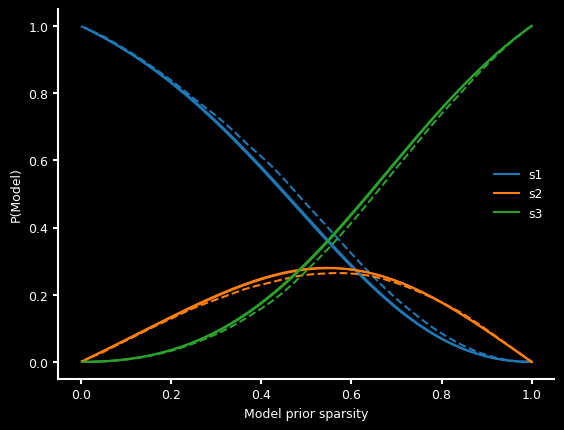

In [161]:
for i, (c1, c2, c3) in enumerate([(0.122, 0.467, 0.706), (1.0, 0.498, 0.055), (0.173, 0.627, 0.173)]):
    _ = plt.plot(ps, np.stack([p[0] for p in ps_mc])[:,i], color=(c1, c2, c3))
    _ = plt.plot(ps, np.stack([p[1] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[2] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[3] for p in ps_mc])[:,i], color=(c1, c2, c3))
    # _ = plt.plot(ps, np.stack([p[4] for p in ps_mc])[:,i], color=(c1, c2, c3))
    _ = plt.plot(ps, np.stack(ps_est)[:,i], '--', color=(c1, c2, c3))

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])

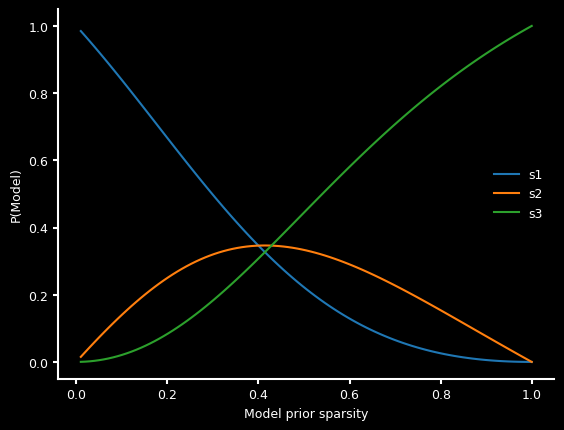

In [162]:

_ = plt.plot(ps, prior_probs[:,0], color=(0.122, 0.467, 0.706))
_ = plt.plot(ps, prior_probs[:,1], color=(1.0, 0.498, 0.055))
_ = plt.plot(ps, prior_probs[:,2], color=(0.173, 0.627, 0.173))

plt.xlabel("Model prior sparsity")
plt.ylabel("P(Model)")
plt.legend([plt.Line2D([0], [0], color=(0.122, 0.467, 0.706), label='s1'),
           plt.Line2D([0], [0], color=(1.0, 0.498, 0.055), label='s2'),
           plt.Line2D([0], [0], color=(0.173, 0.627, 0.173), label='s3')],
          ['s1', 's2', 's3'])

In [47]:
# Estiamte by model
p_ball_stick1_est = model.log_prob_mask(jnp.array([True, True, False, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
p_ball_stick1_stick2_est = model.log_prob_mask(jnp.array([True, True, True, False, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))
p_ball_s123 =  model.log_prob_mask(jnp.array([True, True, True, True, True]), acq.bvals, acq.bvecs, x_o, jnp.array([p_prior]))


ps_est = jnp.stack([p_ball_stick1_est, p_ball_stick1_stick2_est, p_ball_s123], axis=-1)
ps_est = jax.nn.softmax(ps_est, axis=-1)
ps_est


Array([0.   , 0.358, 0.642], dtype=float32)

In [30]:
from blackjax import hmc, tempered_smc
from blackjax.smc.resampling import systematic
from functools import partial
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

def log_likelihood_fn(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def posterior_pred(theta, rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def smc(rng,thetas,model_mask, acq, x_o):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.005, num_integration_steps=2, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic
    _log_likelihood_fn = partial(log_likelihood_fn, mask=model_mask, acq=acq, x=x_o)
    smc = tempered_smc(log_prior_fn, _log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state =state._replace(lmbda=0.99)
        new_state, info = smc.step(rng, state, 1.)
        return new_state, info

    rng_keys = jax.random.split(rng, 3)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles, final_state.weights


def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    K = 50
    propose_fn = partial(model.sample_theta, num_steps=32, max_noise=80)
    key_k = jax.random.split(key, K)
    theta = jax.vmap(propose_fn, in_axes=(0,None,None,None, None))(key_k, acq.bvals, acq.bvecs, x,model_mask)
    theta_corr, weights = smc(subkey, theta, model_mask, acq, x)
    # theta_corr = theta
    # weights = None
    return theta_corr, weights

sample_theta_per_x = jax.jit(jax.vmap(sample_mcmc_correct))

In [24]:
full_data_flat_in_brain.shape[0] / 6

37973.333333333336

In [29]:
thetas_corr, weights = sample_theta_per_x(jax.random.split(jax.random.key(0), 38000), full_data_flat_in_brain[1000:39000])

In [26]:
jnp.mean(1/jnp.sum(weights**2,-1))

Array(49.6, dtype=float32)

In [194]:
xs_pred = jax.vmap(jax.vmap(posterior_pred, in_axes=(0,None)))(thetas_corr, jax.random.split(jax.random.key(0), 20000))

In [195]:
xs_pred

(20000, 50, 105)

In [197]:
(xs_pred.mean(1) - full_data_flat_in_brain[1000:21000]).mean(0)

Array([-0.021, -0.008,  0.011,  0.007,  0.014, -0.021, -0.015, -0.017,
       -0.013, -0.016, -0.012, -0.01 , -0.016, -0.018, -0.011, -0.018,
       -0.013, -0.012, -0.013, -0.008, -0.009, -0.011, -0.011, -0.013,
       -0.015, -0.01 , -0.018, -0.015, -0.014, -0.013, -0.014, -0.018,
       -0.011, -0.01 , -0.005, -0.01 , -0.014, -0.006, -0.012, -0.011,
       -0.013, -0.01 , -0.011, -0.007, -0.012, -0.01 , -0.007, -0.009,
       -0.009, -0.011, -0.011, -0.014, -0.01 , -0.01 , -0.017, -0.027,
       -0.031, -0.033, -0.032, -0.032, -0.031, -0.027, -0.028, -0.034,
       -0.028, -0.027, -0.028, -0.031, -0.028, -0.029, -0.031, -0.028,
       -0.03 , -0.032, -0.029, -0.027, -0.028, -0.027, -0.027, -0.025,
       -0.029, -0.031, -0.031, -0.031, -0.032, -0.027, -0.03 , -0.028,
       -0.026, -0.025, -0.023, -0.026, -0.026, -0.031, -0.028, -0.031,
       -0.027, -0.029, -0.029, -0.025, -0.027, -0.024, -0.029, -0.027,
       -0.023], dtype=float32)

In [181]:
thetas_corr.sum()

Array(nan, dtype=float32)

In [198]:

#sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 20_000
key = jax.random.key(0)
thetas_full = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = np.array(batch_thetas)
    thetas_full.append(batch_thetas)
    #print(ess.mean())
thetas_full = np.concatenate(thetas_full, axis=0)


Batch 0
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


KeyboardInterrupt: 

In [530]:
# Sample masks whole brain

def sample_mask_per_x(key, x):
    keys = jax.random.split(key, 500)
    return jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(keys, acq.bvals, acq.bvecs, x, jnp.array([0.1]))

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


In [531]:
jax.clear_caches()

In [532]:


batch_size = 1_000
key = jax.random.key(0)
masks_brain = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    masks_brain.append(batch_masks)
masks_brain = np.concatenate(masks_brain, axis=0)


Batch 0
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Batch 16000
Batch 17000
Batch 18000
Batch 19000
Batch 20000
Batch 21000
Batch 22000
Batch 23000
Batch 24000
Batch 25000
Batch 26000
Batch 27000
Batch 28000
Batch 29000
Batch 30000
Batch 31000
Batch 32000
Batch 33000
Batch 34000
Batch 35000
Batch 36000
Batch 37000
Batch 38000
Batch 39000
Batch 40000
Batch 41000
Batch 42000
Batch 43000
Batch 44000
Batch 45000
Batch 46000
Batch 47000
Batch 48000
Batch 49000
Batch 50000
Batch 51000
Batch 52000
Batch 53000
Batch 54000
Batch 55000
Batch 56000
Batch 57000
Batch 58000
Batch 59000
Batch 60000
Batch 61000
Batch 62000
Batch 63000
Batch 64000
Batch 65000
Batch 66000
Batch 67000
Batch 68000
Batch 69000
Batch 70000
Batch 71000
Batch 72000
Batch 73000
Batch 74000
Batch 75000
Batch 76000
Batch 77000
Batch 78000
Batch 79000
Batch 80000
Batch 81000
Batch 82000
Batch 83000
Batch

In [533]:
full_data_flat.shape

(778752, 105)

In [534]:
ball = jnp.array([True, False, False, False, True])
ball_stick1 = jnp.array([True, True, False, False, True])
ball_stick2 = jnp.array([True, False, True, False, True])
ball_stick3 = jnp.array([True, False, False, True, True])

ball_stick1_stick2 = jnp.array([True, True, True, False, True])
ball_stick1_stick3 = jnp.array([True, True, False, True, True])
ball_stick2_stick3 = jnp.array([True, False, True, True, True])

ball_stick1_stick2_stick3 = jnp.array([True, True, True, True, True])

p_ball = (masks_brain == ball).all(-1).mean(1)

p_ball_stick1 = (masks_brain == ball_stick1).all(-1).mean(1)
p_ball_stick2 = (masks_brain == ball_stick2).all(-1).mean(1)
p_ball_stick3 = (masks_brain == ball_stick3).all(-1).mean(1)

p_ball_stick1_stick2 = (masks_brain == ball_stick1_stick2).all(-1).mean(1)
p_ball_stick1_stick3 = (masks_brain == ball_stick1_stick3).all(-1).mean(1)
p_ball_stick2_stick3 = (masks_brain == ball_stick2_stick3).all(-1).mean(1)

p_ball_stick1_stick2_stick3 = (masks_brain == ball_stick1_stick2_stick3).all(-1).mean(1)

p_sim_configs = jnp.stack([p_ball, p_ball_stick1, p_ball_stick2, p_ball_stick3, p_ball_stick1_stick2, p_ball_stick1_stick3, p_ball_stick2_stick3, p_ball_stick1_stick2_stick3], axis=-1)
p_sim_configs = p_sim_configs / (p_sim_configs.sum(-1, keepdims=True) + 1e-10)

In [582]:
p_sim_configs.mean(0)

Array([0.038, 0.045, 0.033, 0.04 , 0.152, 0.067, 0.056, 0.568], dtype=float32)

: 

In [536]:
best_model = p_sim_configs.argmax(1)

In [537]:
marginal_probs = masks_brain.mean(1)
full_brain_marginal_probs = np.zeros((full_data_flat.shape[0], 5))
full_brain_marginal_probs[brain_mask_flat.astype(np.bool),...] = marginal_probs
full_brain_marginal_probs = full_brain_marginal_probs.reshape(data_norm.shape[:-1] + (5,))

In [538]:
full_p_sim_configs = np.zeros((full_data_flat.shape[0], 8))
full_p_sim_configs[brain_mask_flat.astype(np.bool),...] = p_sim_configs
full_p_sim_configs = full_p_sim_configs.reshape(data_norm.shape[:-1] + (8,))

In [539]:
full_best_model = np.zeros(full_data_flat.shape[0])
full_best_model[brain_mask_flat.astype(np.bool)] = best_model
full_best_model = full_best_model.reshape(data_norm.shape[:-1])

In [540]:
p_sim_configs.shape

(227840, 8)

In [543]:
np.quantile(marginal_probs[...,3], (0.05, 0.5,0.95))

array([0.202, 0.892, 1.   ])

In [544]:
p_sim_1stick = p_sim_configs[...,1:4].sum(-1)
p_sim_2stick = p_sim_configs[...,4:7].sum(-1)
p_sim_3stick = p_sim_configs[...,7:8].sum(-1)
p_stick_configs = jnp.stack([p_sim_1stick, p_sim_2stick, p_sim_3stick], axis=-1)
full_p_stick_configs = np.zeros((full_data_flat.shape[0], 3))
full_p_stick_configs[brain_mask_flat.astype(np.bool),...] = p_stick_configs
full_p_stick_configs = full_p_stick_configs.reshape(data_norm.shape[:-1] + (3,))


In [581]:
p_stick_configs.mean(0) / p_stick_configs.mean(0).sum()

Array([0.123, 0.286, 0.591], dtype=float32)

<OrthoSlicer3D: (104, 104, 72)>

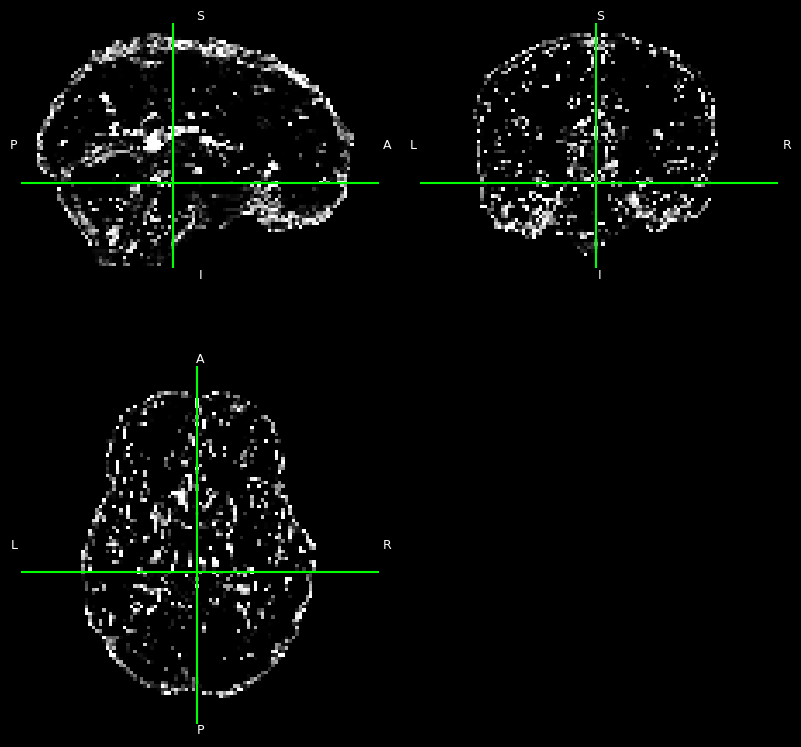

In [555]:
%matplotlib inline
import nibabel as nb
nb.Nifti1Image(full_p_stick_configs[...,0], affine).orthoview()